In [159]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Logistic Regression

### Data Example

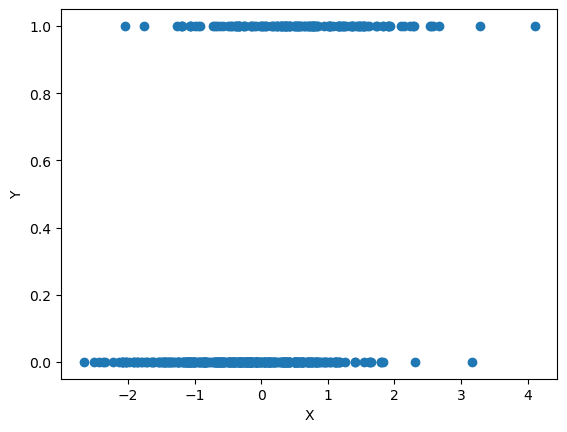

In [160]:
np.random.seed(2)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

n = 500

# Generate a synthetic dataset with a single feature
X = np.random.randn(n, 1) 

beta1 = 1
beta0 = -1

Y = np.random.binomial(1, sigmoid(beta0 + beta1 * X))
Y = Y.ravel()


## plot X against Y
plt.scatter(X, Y)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Gradient descent demonstration

In [161]:
def compute_loss(X, y, weights):
    n = X.shape[0]
    prob_pred = sigmoid(X @ weights)
    loss = (-1 / n) * np.sum(y * np.log(prob_pred) + (1 - y) * np.log(1 - prob_pred))
    return loss


def gradient_descent(X, y, weights, learning_rate, iterations):
    n = X.shape[0]

    loss = compute_loss(X, y, weights)
    loss_history = [loss]
    weight_history = [weights.copy()]

    for i in range(iterations):
        prob_pred = sigmoid(X @ weights)
        gradient = X.T @ (prob_pred - y) / n    
        weights -= learning_rate * gradient   ## weights = weights - learning_rate * gradient
        loss = compute_loss(X, y, weights)
        loss_history.append(loss)
        weight_history.append(weights.copy())
    
    return weights, loss_history, weight_history


In [162]:
# Add intercept to X
Xint = np.hstack((np.ones((X.shape[0], 1)), X))

# Initialize weights
init_weights = np.array([3.0, -3.0])

# Perform Gradient Descent
learning_rate = 1
niter = 50
weights, loss_history, weight_history = gradient_descent(Xint, Y, init_weights, learning_rate, iterations=niter)

## compare estimated weights with true weights
print('Estimated weights:', weights)
print('True weights:', np.array([beta0, beta1]))

Estimated weights: [-1.03069446  0.98343896]
True weights: [-1  1]


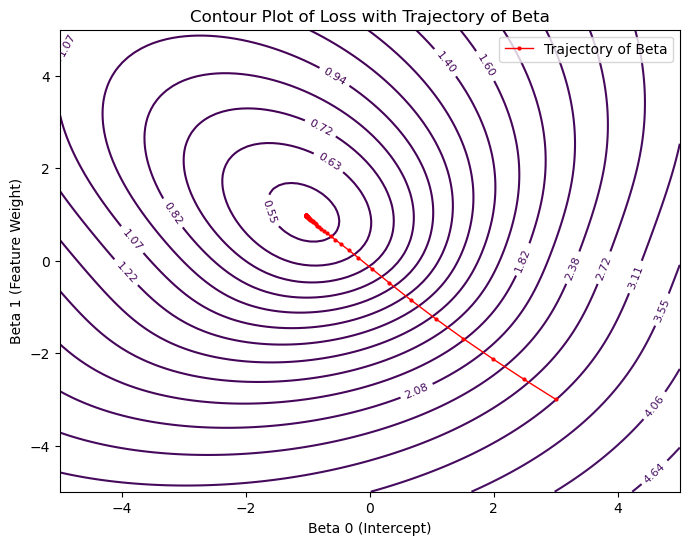

In [163]:
# Create a grid for contour plot
beta0_range = np.linspace(-5, 5, 100)
beta1_range = np.linspace(-5, 5, 100)
B0, B1 = np.meshgrid(beta0_range, beta1_range)

# Compute loss for each combination in the grid
Loss = np.zeros(B0.shape)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        Loss[i, j] = compute_loss(Xint, Y, np.array([B0[i, j], B1[i, j]]))

# Plotting
plt.figure(figsize=(8, 6))
# Contour plot for the loss
contour = plt.contour(B0, B1, Loss, levels=np.logspace(-2, 2, 70), cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# Overlay the trajectory of beta
beta_trajectory = np.array(weight_history)
plt.plot(beta_trajectory[:, 0], beta_trajectory[:, 1], '-o', color='red', label='Trajectory of Beta', lw=1, markersize=2)

plt.title('Contour Plot of Loss with Trajectory of Beta')
plt.xlabel('Beta 0 (Intercept)')
plt.ylabel('Beta 1 (Feature Weight)')
plt.legend()
plt.show()


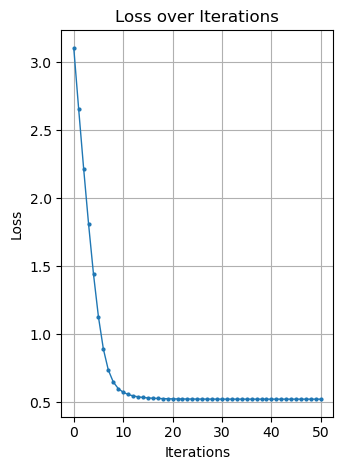

In [164]:
# Plot for Loss over Iterations
plt.subplot(1, 2, 2)
plt.plot(loss_history, '-o', markersize=2, lw=1)
plt.title('Loss over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

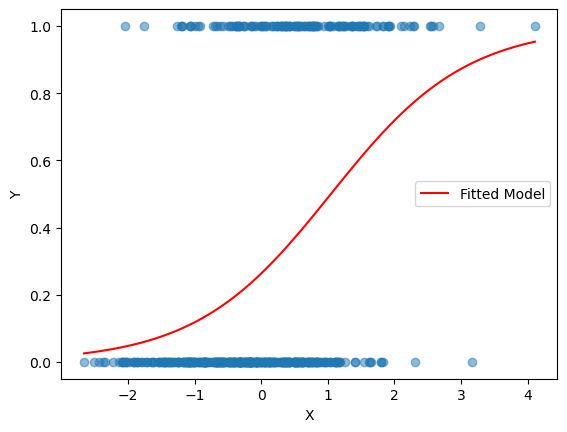

In [165]:
import matplotlib.pyplot as plt

# Scatter plot of X vs Y
plt.scatter(X, Y, alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')

# Generate x values for the sigmoid curve
x_vals = np.linspace(X.min(), X.max(), 100)
# Compute sigmoid with learned weights
sigmoid_vals = sigmoid(weights[0] + weights[1] * x_vals)
plt.plot(x_vals, sigmoid_vals, color='red', label='Fitted Model')
plt.legend()
plt.show()

## Stock Market Data

*Adapted from Introduction to Statistical Learning with Python* [(link)](https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch02-statlearn-lab.ipynb)

We now examine the `Smarket` data, which is part of the `ISLP` library. This data set consists of percentage returns for the S&P 500 stock index over 1,250 days, from the beginning of 2001 until the end of 2005. For each date, we have recorded the percentage returns for each of the five previous trading days,  `Lag1`  through `Lag5`. We have also recorded  `Volume`  (the number of shares traded on the previous day, in billions),  `Today`  (the percentage return on the date in question) and  `Direction` (whether the market was  `Up`  or  `Down`  on this date).

If you do not have the `ISLP` package, install it by going to your terminal (e.g. in VSCode or Anaconda Prompt):

```{.bash}
conda activate stat486
pip install ISLP
```

In [166]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Loading the `SMarket` data:

In [167]:
Smarket = load_data('Smarket')
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


In [168]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

We compute the correlation matrix using the `corr()` method
for data frames, which produces a matrix that contains all of
the pairwise correlations among the variables.
 
By instructing `pandas` to use only numeric variables, the `corr()` method does not report a correlation for the `Direction`  variable because it is
 qualitative.

In [169]:
Smarket.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


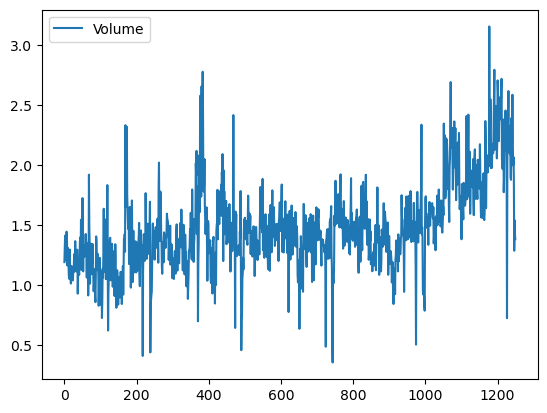

In [170]:
Smarket.plot(y='Volume');


In [171]:
allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
X = Smarket[allvars]
Xint = np.hstack((np.ones((X.shape[0], 1)), X))
y = Smarket.Direction == 'Up'

train = (Smarket.Year < 2005)
X_train, X_test = Xint[train], Xint[~train]
y_train, y_test = y[train], y[~train]

### Logistic Regression
Next, we will fit a logistic regression model in order to predict
 `Direction`  using  `Lag1`  through  `Lag5`  and
 `Volume`. The `sm.GLM()`  function fits *generalized linear models*, a class of
models that includes logistic regression.  Alternatively,
the function `sm.Logit()` fits a logistic regression
model directly. The syntax of
`sm.GLM()` is similar to that of `sm.OLS()`, except
that we must pass in the argument `family=sm.families.Binomial()`
in order to tell `statsmodels` to run a logistic regression rather than some other
type of generalized linear model.

In [172]:
glm = sm.GLM(y_train,
             X_train,
             family=sm.families.Binomial())
results = glm.fit()
coeffs = results.params

In [173]:
features_list = ['Intercept'] + list(X.columns)
print("Coefficients:")
for i, f in enumerate(features_list):
    print(f"{f}: {coeffs[i]:.4f}")

Coefficients:
Intercept: 0.1912
Lag1: -0.0542
Lag2: -0.0458
Lag3: 0.0072
Lag4: 0.0064
Lag5: -0.0042
Volume: -0.1163


In [174]:
probs = results.predict(X_test)

In [175]:
# turn predictions in to labels
labels = np.array(['Down']*len(probs))
labels[probs>0.5] = "Up"

In [176]:
# turn test data into labels
L_test = np.array(['Down']*len(probs))
L_test[y_test == 1] = 'Up'

In [177]:
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


In [178]:
np.mean(labels == L_test), (77+44)/len(L_test)

(np.float64(0.4801587301587302), 0.4801587301587302)

It is worse than random guessing!

Let's try just Lag 1 and Lag 2.

In [179]:
X = Smarket[['Lag1', 'Lag2']]
Xint = np.hstack((np.ones((X.shape[0], 1)), X))
y = Smarket.Direction == 'Up'

train = (Smarket.Year < 2005)
X_train, X_test = Xint[train], Xint[~train]
y_train, y_test = y[train], y[~train]

In [180]:
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

labels = np.array(['Down']*len(y_test))
labels[probs>0.5] = 'Up'

L_test = np.array(['Down']*len(probs))
L_test[y_test == 1] = 'Up'

confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [181]:
np.mean(labels == L_test)

np.float64(0.5595238095238095)

A bit better! We will talk about how to do more systematic feature selection next class.